# 02. Bifurcation diagram and the Lyapunov exponent

Notebook 01 watched the logistic map period-double into chaos as the growth
rate `r` was raised. This notebook does two things with that route: maps it in
full, then measures it. The **bifurcation diagram** plots the attractor of the
map at every `r` across a fine grid, so the cascade and the chaotic bands are
read off directly. The **Lyapunov exponent** measures the same thing as a
number: it is the average exponential rate at which nearby orbits separate,
negative in the stable windows and positive in chaos. The two come from the same
sweep and are stacked one above the other, and the points where the exponent
crosses zero line up with the splittings in the diagram.

The sweep is the heavy step, so it runs in `scripts/run_bifurcation.py` and is
read back here from `artifacts/`. This notebook loads the arrays and draws
them.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from nldynamics.plotting import palette, setup_style


def project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "nldynamics").exists():
            return parent
    return Path.cwd()


setup_style()
ROOT = project_root()
data = np.load(ROOT / "artifacts" / "bifurcation.npz")
r_grid = data["r_grid"]
r_points, x_points = data["r_points"], data["x_points"]
exponent = data["exponent"]

## The sweep

A grid of a few thousand growth rates spans the interesting range, from the
stable regime at `r = 2.5` to the edge of the parameter space at `r = 4.0`.
Every value is iterated from the same small seed. A transient is discarded so
the orbit settles onto its attractor, and the last hundred iterates are kept as
the sampled attractor. The Lyapunov exponent is averaged over the same orbits,
so the diagram and the exponent never disagree about which run they describe.

In [2]:
crossings = np.sum(np.diff(np.sign(exponent)) != 0)
print(f"{r_points.size:,} attractor points across {r_grid.size:,} growth rates")
print(f"exponent ranges {exponent.min():.2f} to {exponent.max():.2f}; {crossings} sign changes")

400,000 attractor points across 4,000 growth rates
exponent ranges -3.71 to 0.69; 35 sign changes


## Reading the two together

Now stack the diagram above the exponent and read them together. Wherever the
diagram is a finite set of curves the exponent is negative: perturbations decay
onto a periodic attractor. Wherever the diagram fills in, the exponent is
positive: orbits diverge, which is what chaos means. The exponent dips back
below zero inside the periodic windows, clearest at the period-three window near
`r = 3.83`, where the chaotic band briefly gives way to order. This is the
figure used in the README.

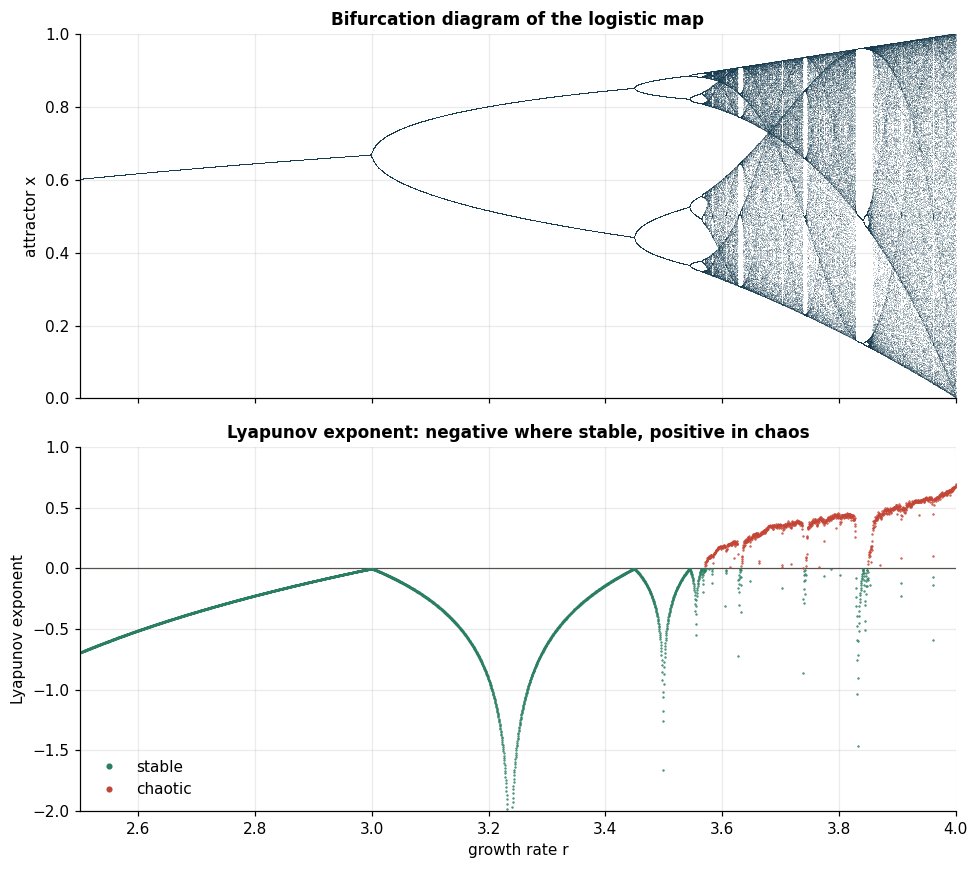

In [3]:
fig, (ax_bif, ax_lyap) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_bif.plot(r_points, x_points, ",", color=palette("attractor"), alpha=0.25)
ax_bif.set_xlim(2.5, 4.0)
ax_bif.set_ylim(0, 1)
ax_bif.set_ylabel("attractor x")
ax_bif.set_title("Bifurcation diagram of the logistic map")

ax_lyap.axhline(0.0, color=palette("diagonal"), lw=0.8)
stable = exponent < 0
ax_lyap.plot(r_grid[stable], exponent[stable], ".", color=palette("stable"), ms=1.0, label="stable")
ax_lyap.plot(
    r_grid[~stable], exponent[~stable], ".", color=palette("chaotic"), ms=1.0, label="chaotic"
)
ax_lyap.set_xlim(2.5, 4.0)
ax_lyap.set_ylim(-2, 1)
ax_lyap.set_xlabel("growth rate r")
ax_lyap.set_ylabel("Lyapunov exponent")
ax_lyap.set_title("Lyapunov exponent: negative where stable, positive in chaos")
ax_lyap.legend(loc="lower left", markerscale=6)
fig.tight_layout()
plt.show()

## The onset of chaos

Zoom on the band where the cascade accumulates and you can watch the period
doublings crowd together towards the Feigenbaum point near `r ≈ 3.5699`, beyond
which the exponent first turns positive. The doublings arrive geometrically,
each window roughly 4.669 times shorter than the last, the Feigenbaum ratio.

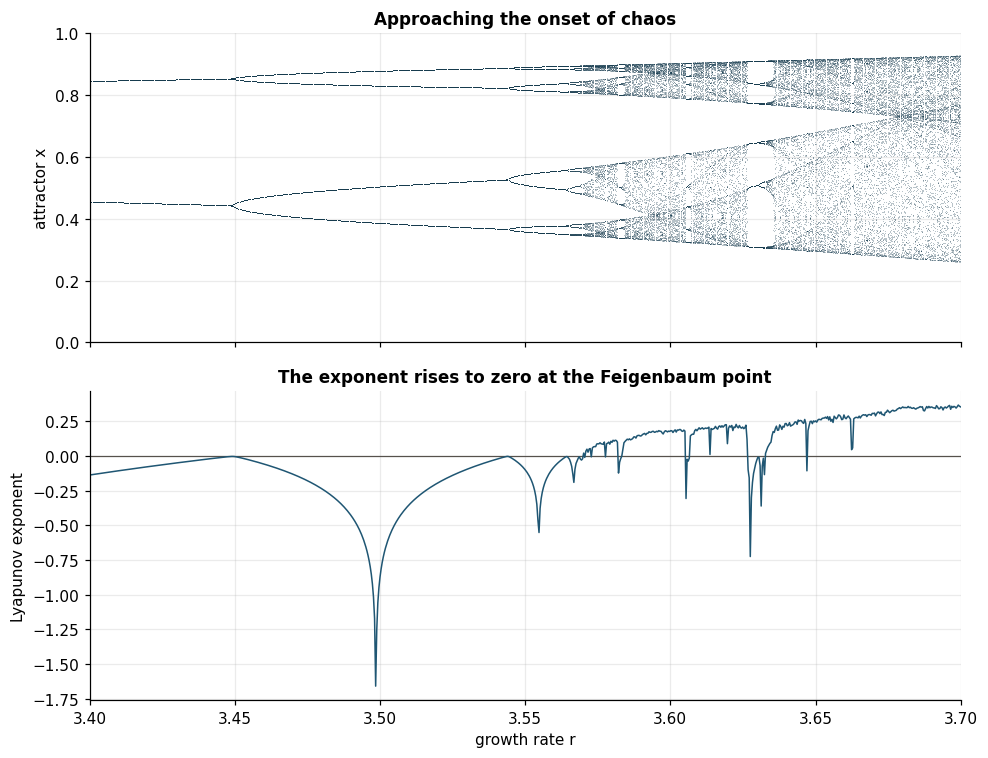

In [4]:
window = (r_grid >= 3.4) & (r_grid <= 3.7)
mask = (r_points >= 3.4) & (r_points <= 3.7)
fig, (ax_bif, ax_lyap) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax_bif.plot(r_points[mask], x_points[mask], ",", color=palette("attractor"), alpha=0.3)
ax_bif.set_ylim(0, 1)
ax_bif.set_ylabel("attractor x")
ax_bif.set_title("Approaching the onset of chaos")
ax_lyap.axhline(0.0, color=palette("diagonal"), lw=0.8)
ax_lyap.plot(r_grid[window], exponent[window], color=palette("orbit"), lw=1.0)
ax_lyap.set_xlim(3.4, 3.7)
ax_lyap.set_xlabel("growth rate r")
ax_lyap.set_ylabel("Lyapunov exponent")
ax_lyap.set_title("The exponent rises to zero at the Feigenbaum point")
fig.tight_layout()
plt.show()

The exponent climbs towards zero through the cascade, touching it at each
doubling, and first becomes positive where the doublings accumulate. Past that
point the periodic windows are the negative dips in an otherwise positive
exponent.

## Summary

- The bifurcation diagram, swept over a few thousand growth rates, renders the
  full period-doubling cascade and the chaotic bands beyond it.
- The Lyapunov exponent measures the chaos: negative where orbits converge onto
  a periodic attractor, positive where they diverge.
- The two agree point for point (the exponent crosses zero where the diagram
  splits or fills), and both show the period-three window reopening near
  `r = 3.83`.
- The doublings crowd together geometrically towards the Feigenbaum point near
  `r ≈ 3.5699`, where the exponent first turns positive.